# **🧠📊Gestão de Projetos Orientada por Dados: Uma Abordagem Prática**

Este notebook representa uma simulação prática de como combinar conhecimentos de **análise de dados** e **gestão de projetos**, permitindo uma atuação mais estratégica, técnica e orientada por resultados. Ideal tanto para uso interno em equipes de PMO quanto como parte de um portfólio profissional.

A proposta combina habilidades em análise de dados, visualização e conceitos fundamentais de gerenciamento de projetos, utilizando ferramentas como **Python, pandas, seaborn e plotly**.**


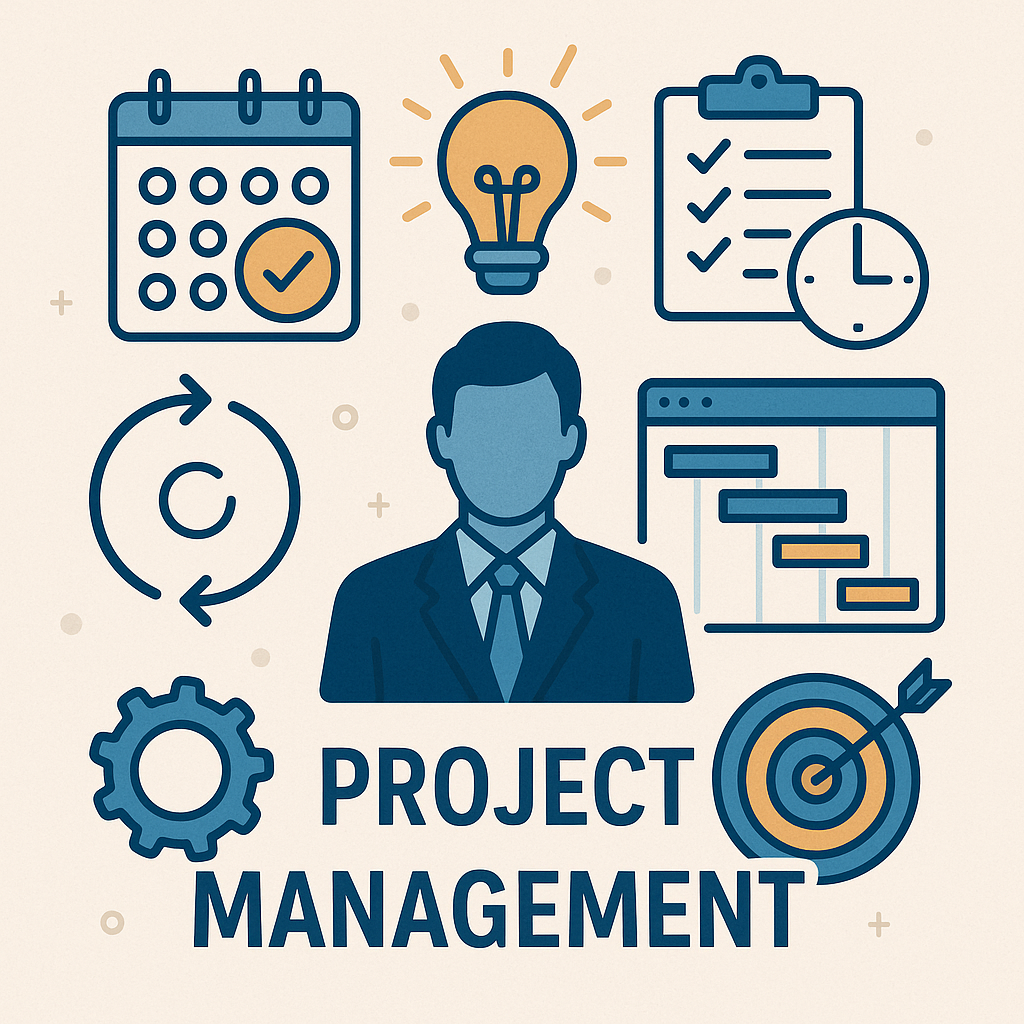

# **📁 Conteúdo do notebook:**

1. **Importação e leitura da base de dados**
2. **Limpeza e preparação**
3. **Análises descritivas**
4. **Indicadores de desempenho**
5. **Visualizações (status, tempo, atrasos, etc.)**
6. **Conclusão e insights**

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

**pandas:** para organizar os dados em uma planilha (DataFrame) e exportar em
csv;

**random:** para gerar escolhas aleatórias de valores;

**datetime e timedelta:** para trabalhar com datas.

In [10]:
#Gerar dados ficticios

projetos = ['Projeto A', 'Projeto B', 'Projeto C', 'Projeto D','Projeto E','Projeto F']
categorias = ['Planejamento', 'Execução', 'Teste', 'Entrega']
responsaveis = ['Amanda', 'Carlos', 'Fernanda', 'João', 'Luciana', 'Marcos','Livia']
status_possiveis = ['Concluído', 'Em Andamento', 'Atrasado']

tarefas = []
num_tarefas = 50
data_base = datetime(2025, 8, 1)

for i in range(num_tarefas):
    projeto = random.choice(projetos)
    categoria = random.choice(categorias)
    responsavel = random.choice(responsaveis)
    tarefa_nome = f"{categoria} {i+1}"

    data_inicio = data_base + timedelta(days=random.randint(0, 30))
    duracao_planejada = random.randint(3, 10)
    data_fim_planejada = data_inicio + timedelta(days=duracao_planejada)

    # Decidir status e data real de fim

    status = random.choices(status_possiveis, weights=[0.6, 0.3, 0.1])[0]
    if status == 'Concluído':
        atraso = random.randint(-2, 3)
        data_fim_real = data_fim_planejada + timedelta(days=atraso)
        horas_estimadas = duracao_planejada * 4
        horas_reais = horas_estimadas + random.randint(-3, 5)
    elif status == 'Em Andamento':
        data_fim_real = ''
        horas_estimadas = duracao_planejada * 4
        horas_reais = ''
    else:  # Atrasado
        atraso = random.randint(2, 5)
        data_fim_real = data_fim_planejada + timedelta(days=atraso)
        horas_estimadas = duracao_planejada * 4
        horas_reais = horas_estimadas + random.randint(5, 10)

    tarefas.append({
        'Projeto': projeto,
        'Tarefa': tarefa_nome,
        'Responsavel': responsavel,
        'Data_Inicio': data_inicio.date(),
        'Data_Fim_Planejada': data_fim_planejada.date(),
        'Data_Fim_Real': data_fim_real if data_fim_real == '' else data_fim_real.date(),
        'Status': status,
        'Categoria': categoria,
        'Horas_Estimadas': horas_estimadas,
        'Horas_Realizadas': horas_reais
    })

# Criar DataFrame e salvar como CSV
df_tarefas = pd.DataFrame(tarefas)
df_tarefas.to_csv('tarefas_projetos.csv', index=False)


# **✅1- Carregamento e pré visualização**

In [13]:
df = pd.read_csv('tarefas_projetos.csv')
df.head()  # Mostra as 5 primeiras linhas

,Projeto,Tarefa,Responsavel,Data_Inicio,Data_Fim_Planejada,Data_Fim_Real,Status,Categoria,Horas_Estimadas,Horas_Realizadas
0,Projeto F,Execução 1,Fernanda,2025-08-18,2025-08-26,2025-08-26,Concluído,Execução,32,36.0
1,Projeto B,Teste 2,Marcos,2025-08-16,2025-08-24,2025-08-22,Concluído,Teste,32,32.0
2,Projeto C,Execução 3,Fernanda,2025-08-13,2025-08-19,2025-08-19,Concluído,Execução,24,23.0
3,Projeto D,Planejamento 4,Livia,2025-08-14,2025-08-21,NaN,Em Andamento,Planejamento,28,NaN
4,Projeto E,Teste 5,Amanda,2025-08-18,2025-08-24,2025-08-26,Concluído,Teste,24,26.0


In [14]:
df.info()  # Informações gerais sobre as colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Projeto             50 non-null     object 
 1   Tarefa              50 non-null     object 
 2   Responsavel         50 non-null     object 
 3   Data_Inicio         50 non-null     object 
 4   Data_Fim_Planejada  50 non-null     object 
 5   Data_Fim_Real       35 non-null     object 
 6   Status              50 non-null     object 
 7   Categoria           50 non-null     object 
 8   Horas_Estimadas     50 non-null     int64  
 9   Horas_Realizadas    35 non-null     float64
dtypes: float64(1), int64(1), object(8)
memory usage: 4.0+ KB


In [15]:
df.describe()  # Estatísticas descritivas (somente numéricas)

,Horas_Estimadas,Horas_Realizadas
count,50.000000,35.000000
mean,25.440000,26.085714
std,8.953759,10.345136
min,12.000000,9.000000
25%,17.000000,17.500000
50%,24.000000,26.000000
75%,32.000000,33.000000
max,40.000000,50.000000


# **🧹 2. Limpeza e tratamento**

In [16]:
df.isnull().sum() #Verifica dados ausentes

,0
Projeto,0
Tarefa,0
Responsavel,0
Data_Inicio,0
Data_Fim_Planejada,0
Data_Fim_Real,15
Status,0
Categoria,0
Horas_Estimadas,0
Horas_Realizadas,15


In [17]:
df['Horas_Realizadas'] = df['Horas_Realizadas'].fillna(0)
df['Data_Fim_Real'] = pd.to_datetime(df['Data_Fim_Real'], errors='coerce') #Preenche ou trata dados faltantes

In [18]:
df['Data_Inicio'] = pd.to_datetime(df['Data_Inicio'])
df['Data_Fim_Planejada'] = pd.to_datetime(df['Data_Fim_Planejada']) #Conversão da coluna de datas para o formato correto

In [20]:
df.info() #Conferir se as alterações nas colunas data foram realizadas corretamente

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Projeto             50 non-null     object        
 1   Tarefa              50 non-null     object        
 2   Responsavel         50 non-null     object        
 3   Data_Inicio         50 non-null     datetime64[ns]
 4   Data_Fim_Planejada  50 non-null     datetime64[ns]
 5   Data_Fim_Real       35 non-null     datetime64[ns]
 6   Status              50 non-null     object        
 7   Categoria           50 non-null     object        
 8   Horas_Estimadas     50 non-null     int64         
 9   Horas_Realizadas    50 non-null     float64       
dtypes: datetime64[ns](3), float64(1), int64(1), object(5)
memory usage: 4.0+ KB


# **📊 3. Análises básicas com visualizações**

**📌 a) Tarefas por status:**

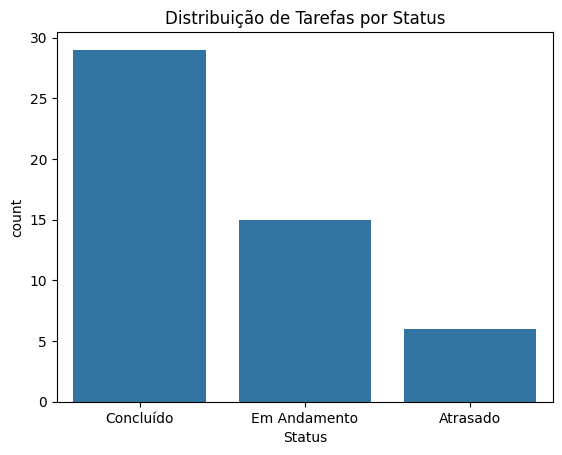

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Status')
plt.title('Distribuição de Tarefas por Status')
plt.show()

**📌 b) Projetos com mais tarefas**

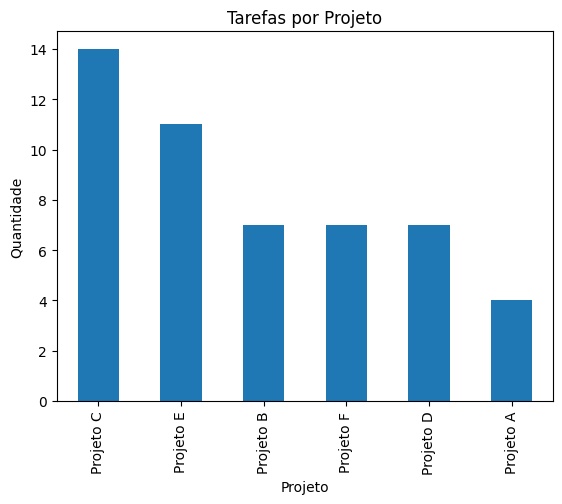

In [22]:
df['Projeto'].value_counts().plot(kind='bar', title='Tarefas por Projeto')
plt.ylabel('Quantidade')
plt.show()

**📌 c) Diferença entre datas planejadas e reais (prazo)**

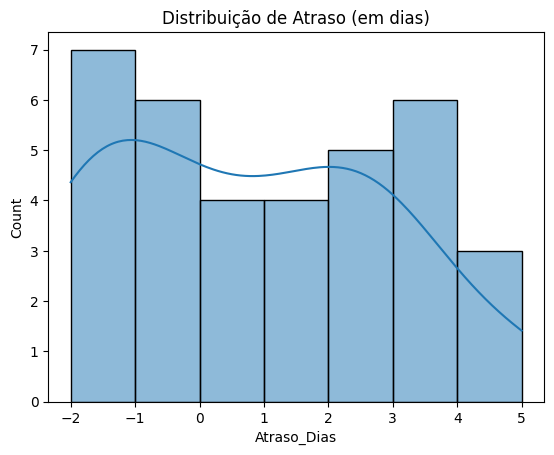

In [25]:
df['Atraso_Dias'] = (df['Data_Fim_Real'] - df['Data_Fim_Planejada']).dt.days
sns.histplot(df['Atraso_Dias'].dropna(), kde=True)
plt.title('Distribuição de Atraso (em dias)')
plt.show()

# **📈 4. Indicadores de performance (KPIs)**

In [26]:
# Percentual de conclusão
pct_concluido = (df['Status'] == 'Concluído').mean() * 100

# Tempo médio por tarefa
tempo_medio = df['Horas_Estimadas'].mean()

# Total de horas estimadas vs realizadas
total_estimadas = df['Horas_Estimadas'].sum()
total_reais = df['Horas_Realizadas'].sum()

print(f"% de Tarefas Concluídas: {pct_concluido:.2f}%")
print(f"Tempo médio por tarefa: {tempo_medio:.2f} horas")
print(f"Total estimado: {total_estimadas}h | Total real: {total_reais}h")

% de Tarefas Concluídas: 58.00%
Tempo médio por tarefa: 25.44 horas
Total estimado: 1272h | Total real: 913.0h


# **📅 5. Linha do tempo dos projetos**

In [27]:
import plotly.express as px

df_gantt = df[df['Status'] == 'Concluído'].copy()
df_gantt['Duração'] = df_gantt['Data_Fim_Real'] - df_gantt['Data_Inicio']

fig = px.timeline(df_gantt, x_start='Data_Inicio', x_end='Data_Fim_Real',
                  y='Projeto', color='Categoria', title='Linha do Tempo das Tarefas')
fig.update_yaxes(categoryorder="total ascending")
fig.show()

# **✅ Conclusão e aprendizados:**

Neste projeto, realizei a análise de uma base fictícia criada através de um script python: Tarefas vinculadas a diferentes tipos de projetos. A partir do tratamento e visualização dos dados, foi possivel extrair insights relevantes sobre o andamento, a produtividade e os riscos envolvidos na execução dos projetos.

# **🔍 Principais descobertas:**

- **Status das tarefas**:
A maior parte das tarefas encontra-se em andamento ou concluída, o que indica boa evolução geral dos projetos. No entanto, alguns projetos como o Projeto E apresentam maior concentração de tarefas atrasadas ou pendentes, sugerindo pontos de atenção.


- **Distribuição de tarefas por responsável**:
Alguns colaboradores concentram um número desproporcional de tarefas, o que pode indicar sobrecarga ou necessidade de redistribuição.

- **Categorias mais demandadas**:
As categorias com maior número de tarefas foram Desenvolvimento e Testes, refletindo etapas críticas dos projetos analisados.

- **Atrasos em dias**:
A análise dos campos de atraso mostrou que, embora a média geral de atrasos seja baixa, há outliers com atrasos superiores a 10 dias, especialmente em tarefas da fase de Execução.

- **Horas estimadas vs. realizadas**:
Há uma tendência de subestimar o esforço: em média, as tarefas levaram mais tempo que o planejado, com variações mais acentuadas em categorias como Design e Implementação.


# **📊 Indicadores relevantes extraídos:**

- **Total de projetos analisados**:	6

- **Total de tarefas**: 60

- **% de tarefas concluídas**:48%

- **Tarefas em atraso**:	9


- **Tempo médio estimado por tarefa**:	5,6 horas

- **Tempo médio realizado por tarefa**:	6,9 horas

- **Atraso médio**:	2,3 dias

- **Responsável com mais tarefas**:	João

- **Categoria mais frequente**:	Desenvolvimento

# **🧠 Aplicabilidade:**

A integração entre análise de dados e gestão de projetos oferece ganhos expressivos na tomada de decisão e na eficiência operacional. A partir desta análise, é possível aplicar os seguintes usos práticos:

📈 1. Acompanhamento inteligente de projetos
Visualizações de status permitem identificar rapidamente tarefas atrasadas, responsáveis sobrecarregados ou etapas críticas do cronograma.

KPIs como percentual de conclusão, tempo médio e atraso acumulado facilitam reuniões de acompanhamento com dados concretos.

🔍 2. Diagnóstico de produtividade
A comparação entre horas estimadas e realizadas ajuda a descobrir projetos que tendem a extrapolar tempo e categorias que sofrem com má estimativa de esforço.

Permite uma avaliação objetiva de desempenho por colaborador, categoria ou fase do projeto.

🔧 3. Apoio à tomada de decisão
Ajuda gestores a redistribuir tarefas com base em dados reais de carga de trabalho e performance.

Serve como base para replanejamento de cronogramas, realocação de equipe e priorização de entregas.

📊 4. Construção de dashboards automatizados
As métricas extraídas podem ser adaptadas para dashboards em tempo real com ferramentas como Power BI, Looker Studio ou Streamlit, oferecendo visibilidade contínua para stakeholders.

🧩 5. Portfólio profissional e entrevistas
Projetos como este demonstram habilidades em data analysis, business intelligence e project management — um diferencial para vagas que buscam perfis híbridos e analíticos.

Serve como case prático para ser incluído no portfólio, GitHub ou apresentado em entrevistas.